In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import (
    plot_acf,
    plot_pacf
)
from statsmodels.tools.sm_exceptions import (
    ConvergenceWarning
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
PROJECT_ROOT = Path.cwd().parent

ARIMA_DATA = (
    PROJECT_ROOT
    / "data"
    / "arima"
)

RESULTS = PROJECT_ROOT / "results"

ARIMA_FORECASTS = (
    RESULTS
    / "arima_forecasts"
)

ARIMA_METRICS = (
    RESULTS
    / "arima_metrics"
)

ARIMA_FORECASTS.mkdir(
    parents=True,
    exist_ok=True
)

ARIMA_METRICS.mkdir(
    parents=True,
    exist_ok=True
)

In [3]:
btc_arima = pd.read_csv(
    ARIMA_DATA / "BTCUSD_arima.csv"
)

btc_arima["Date"] = pd.to_datetime(
    btc_arima["Date"]
)

btc_arima = (
    btc_arima
    .sort_values("Date")
    .reset_index(drop=True)
)

btc_arima.head()

,Date,Close,Log_Price,Log_Return
0,2010-07-19,0.08080,-2.515778,NaN
1,2010-07-20,0.07474,-2.593740,-0.077962
2,2010-07-21,0.07921,-2.535653,0.058087
3,2010-07-22,0.05050,-2.985782,-0.450129
4,2010-07-23,0.06262,-2.770671,0.215111


In [4]:
split_idx = int(
    len(btc_arima) * 0.8
)

train_df = btc_arima.iloc[
    :split_idx
].copy()

test_df = btc_arima.iloc[
    split_idx:
].copy()

In [5]:
print(
    "Train:",
    train_df["Date"].min(),
    "→",
    train_df["Date"].max()
)

print(
    "Test:",
    test_df["Date"].min(),
    "→",
    test_df["Date"].max()
)

print(
    "Train samples:",
    len(train_df)
)

print(
    "Test samples:",
    len(test_df)
)

Train: 2010-07-19 00:00:00 → 2023-06-05 00:00:00
Test: 2023-06-06 00:00:00 → 2026-08-26 00:00:00
Train samples: 3334
Test samples: 834


In [6]:
train_log_price = (
    train_df["Log_Price"]
    .dropna()
)

train_log_return = (
    train_df["Log_Return"]
    .dropna()
)

In [7]:
result_price = adfuller(
    train_log_price
)

print("BTCUSD Train Log Price")
print("ADF Statistic:", result_price[0])
print("p-value:", result_price[1])

BTCUSD Train Log Price
ADF Statistic: -3.2502617003852214
p-value: 0.017253545062997998


In [8]:
result_return = adfuller(
    train_log_return
)

print("\nBTCUSD Train Log Return")
print("ADF Statistic:", result_return[0])
print("p-value:", result_return[1])


BTCUSD Train Log Return
ADF Statistic: -13.632818555446443
p-value: 1.7104400587766558e-25


In [9]:
result_price_trend = adfuller(
    train_log_price,
    regression="ct"
)

print("BTCUSD Train Log Price — ADF with Trend")
print("ADF Statistic:", result_price_trend[0])
print("p-value:", result_price_trend[1])

BTCUSD Train Log Price — ADF with Trend
ADF Statistic: -3.134911506523123
p-value: 0.09816853196819186


In [10]:
from statsmodels.tsa.stattools import kpss
kpss_result = kpss(
    train_log_price,
    regression="ct",
    nlags="auto"
)

print("BTCUSD Train Log Price — KPSS")
print("KPSS Statistic:", kpss_result[0])
print("p-value:", kpss_result[1])

BTCUSD Train Log Price — KPSS
KPSS Statistic: 1.0859190573240507
p-value: 0.01


C:\Users\Andywang\AppData\Local\Temp\ipykernel_608\1671866160.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(


In [ ]:
### BTCUSD Stationarity Robustness Check

The default ADF test initially suggested that BTCUSD log price may be stationary.

However, this result was not robust once the long-term trend was explicitly considered.

The trend-adjusted ADF test produced a p-value of 0.0982, meaning the unit-root null could not be rejected at the 5% significance level.

The KPSS test with trend produced a p-value below 0.01, rejecting the null hypothesis of trend stationarity.

Combined with the strongly stationary log-return series, the evidence supports treating BTCUSD log price as non-stationary and using first-order differencing.

Therefore:

d = 1

<Figure size 1000x500 with 0 Axes>

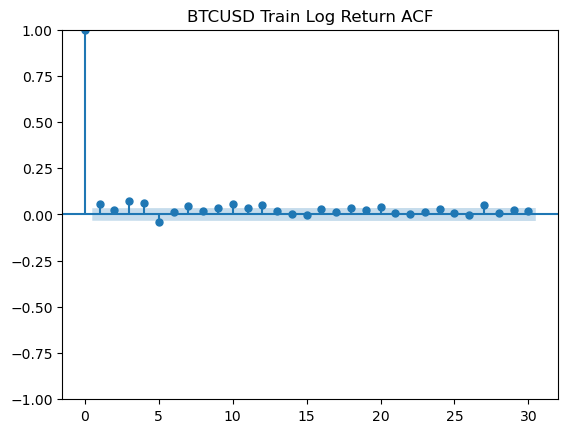

In [11]:
plt.figure(figsize=(10, 5))

plot_acf(
    train_log_return,
    lags=30
)

plt.title("BTCUSD Train Log Return ACF")
plt.show()

<Figure size 1000x500 with 0 Axes>

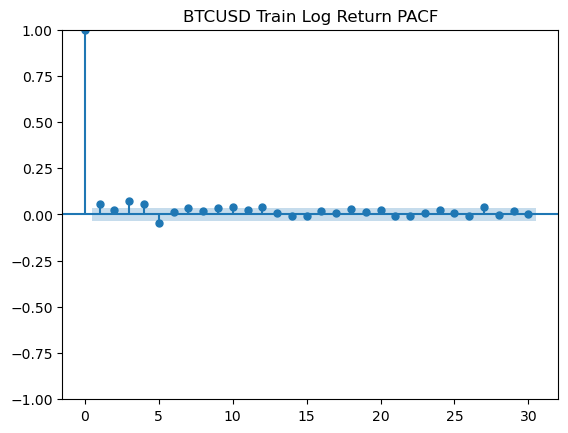

In [12]:
plt.figure(figsize=(10, 5))

plot_pacf(
    train_log_return,
    lags=30,
    method="ywm"
)

plt.title("BTCUSD Train Log Return PACF")
plt.show()

In [13]:
candidate_orders = [
    (0, 1, 0),
    (1, 1, 0),
    (0, 1, 1),
    (1, 1, 1),
    (2, 1, 0),
    (0, 1, 2),
    (2, 1, 1),
    (1, 1, 2)
]

In [14]:
comparison_results = []

for order in candidate_orders:

    model = ARIMA(
        train_log_price,
        order=order,
        trend="n"
    )

    fitted_model = model.fit()

    comparison_results.append({
        "Order": order,
        "AIC": fitted_model.aic,
        "BIC": fitted_model.bic,
        "Converged": fitted_model.mle_retvals.get(
            "converged",
            True
        )
    })

comparison_df = pd.DataFrame(
    comparison_results
)

comparison_df = (
    comparison_df
    .sort_values("AIC")
    .reset_index(drop=True)
)

comparison_df

D:\Anaconda\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
D:\Anaconda\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


,Order,AIC,BIC,Converged
0,"(1, 1, 1)",-9706.702414,-9688.367530,True
1,"(1, 1, 2)",-9705.133697,-9680.687184,True
2,"(2, 1, 1)",-9705.117719,-9680.671207,True
3,"(2, 1, 0)",-9671.781604,-9653.446720,True
4,"(1, 1, 0)",-9671.394318,-9659.171062,True
5,"(0, 1, 1)",-9670.852677,-9658.629421,True
6,"(0, 1, 2)",-9670.294443,-9651.959559,True
7,"(0, 1, 0)",-9662.025478,-9655.913850,True


In [15]:
### BTCUSD ARIMA Order Selection

BTCUSD log returns showed somewhat stronger short-lag autocorrelation than the equity assets, although the overall dependence remained relatively weak.

A broader set of low-order ARIMA specifications was therefore evaluated using the training sample only.

Among the tested models, ARIMA(1,1,1) produced both the lowest AIC and the lowest BIC:

- AIC = -9706.70
- BIC = -9688.37

All candidate models converged successfully.

The improvement in AIC and BIC relative to ARIMA(0,1,0) suggests that the AR(1) and MA(1) components capture additional time-series structure in BTCUSD log prices.

Therefore:

ARIMA(1,1,1)

is selected for out-of-sample BTCUSD forecasting.

The model will next be evaluated over the 30D, 3M, and 6M horizons using walk-forward forecasting.

SyntaxError: invalid decimal literal (3592443957.py, line 22)

In [16]:
BTC_ORDER = (1, 1, 1)

In [17]:
def create_arima_target(
    full_df,
    test_df,
    horizon
):
    horizon_map = {
        "30D": pd.Timedelta(days=30),
        "3M": pd.DateOffset(months=3),
        "6M": pd.DateOffset(months=6)
    }

    if horizon not in horizon_map:
        raise ValueError(
            f"Unsupported horizon: {horizon}"
        )

    target_df = test_df[
        [
            "Date",
            "Close",
            "Log_Price"
        ]
    ].copy()

    target_df["Target_Date"] = (
        target_df["Date"]
        + horizon_map[horizon]
    )

    future_prices = full_df[
        [
            "Date",
            "Close",
            "Log_Price"
        ]
    ].copy()

    future_prices = future_prices.rename(
        columns={
            "Date": "Future_Date",
            "Close": "Future_Close",
            "Log_Price": "Future_Log_Price"
        }
    )

    target_df = pd.merge_asof(
        target_df.sort_values("Target_Date"),
        future_prices.sort_values("Future_Date"),
        left_on="Target_Date",
        right_on="Future_Date",
        direction="forward"
    )

    target_df = target_df.dropna(
        subset=[
            "Future_Date",
            "Future_Close"
        ]
    ).copy()

    return target_df

In [18]:
def run_arima_walk_forward(
    full_df,
    test_target_df,
    order,
    refit_every=5
):
    rolling_results = []

    fitted_model = None
    last_model_date = None

    non_converged = 0
    failed_windows = 0
    skipped_windows = 0
    refit_count = 0

    for i in range(len(test_target_df)):

        row = test_target_df.iloc[i]

        current_date = row["Date"]
        current_close = row["Close"]
        future_date = row["Future_Date"]
        future_close = row["Future_Close"]

        # Count observations between current date
        # and future target date
        forecast_dates = full_df[
            (full_df["Date"] > current_date)
            &
            (full_df["Date"] <= future_date)
        ]

        steps = len(forecast_dates)

        if steps == 0:
            skipped_windows += 1
            continue

        try:

            # Full refit every N observations
            if fitted_model is None or i % refit_every == 0:

                history = full_df[
                    full_df["Date"] <= current_date
                ]["Log_Price"].dropna()

                history_values = history.to_numpy(
                    dtype=float
                )

                model = ARIMA(
                    history_values,
                    order=order,
                    trend="n"
                )

                with warnings.catch_warnings():

                    warnings.simplefilter(
                        "ignore",
                        ConvergenceWarning
                    )

                    fitted_model = model.fit()

                refit_count += 1
                last_model_date = current_date

                converged = (
                    fitted_model
                    .mle_retvals
                    .get("converged", True)
                )

                if not converged:
                    non_converged += 1

            # Between full refits, append latest observations
            else:

                new_data = full_df[
                    (full_df["Date"] > last_model_date)
                    &
                    (full_df["Date"] <= current_date)
                ]["Log_Price"].dropna()

                if len(new_data) > 0:

                    new_values = new_data.to_numpy(
                        dtype=float
                    )

                    fitted_model = fitted_model.append(
                        new_values,
                        refit=False
                    )

                last_model_date = current_date

            # Forecast
            forecast_log = fitted_model.forecast(
                steps=steps
            )

            predicted_log_price = (
                np.asarray(forecast_log)[-1]
            )

            predicted_future_price = np.exp(
                predicted_log_price
            )

            predicted_return = (
                predicted_future_price
                / current_close
                - 1
            )

            actual_return = (
                future_close
                / current_close
                - 1
            )

            rolling_results.append({
                "Date": current_date,
                "Current_Close": current_close,
                "Future_Date": future_date,
                "Forecast_Steps": steps,
                "Actual_Future_Price": future_close,
                "Predicted_Future_Price": predicted_future_price,
                "Actual_Return": actual_return,
                "Predicted_Return": predicted_return
            })

        except Exception as e:

            failed_windows += 1

            print(
                f"Failed on {current_date}: {e}"
            )

    prediction_df = pd.DataFrame(
        rolling_results
    )

    diagnostics = {
        "Forecasts": len(prediction_df),
        "Refit_Count": refit_count,
        "Non_Converged": non_converged,
        "Skipped_Windows": skipped_windows,
        "Failed_Windows": failed_windows
    }

    return prediction_df, diagnostics

In [19]:
def calculate_arima_metrics(
    prediction_df,
    asset_name,
    horizon,
    model_name="ARIMA"
):
    y_true = prediction_df["Actual_Return"]
    y_pred = prediction_df["Predicted_Return"]

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    directional_accuracy = np.mean(
        np.sign(y_true.values)
        ==
        np.sign(y_pred.values)
    )

    baseline_pred = np.zeros(
        len(y_true)
    )

    baseline_mae = mean_absolute_error(
        y_true,
        baseline_pred
    )

    baseline_rmse = np.sqrt(
        mean_squared_error(
            y_true,
            baseline_pred
        )
    )

    mae_improvement = (
        baseline_mae - mae
    )

    rmse_improvement = (
        baseline_rmse - rmse
    )

    metrics_raw = {
        "Asset": asset_name,
        "Model": model_name,
        "Horizon": horizon,
        "Samples": int(len(prediction_df)),

        "MAE": float(mae),
        "RMSE": float(rmse),
        "R2": float(r2),
        "Directional_Accuracy": float(
            directional_accuracy
        ),

        "Baseline_MAE": float(
            baseline_mae
        ),
        "Baseline_RMSE": float(
            baseline_rmse
        ),

        "MAE_Improvement_vs_Baseline": float(
            mae_improvement
        ),
        "RMSE_Improvement_vs_Baseline": float(
            rmse_improvement
        )
    }

    metrics_display = {
        "Asset": asset_name,
        "Model": model_name,
        "Horizon": horizon,
        "Samples": int(len(prediction_df)),

        "MAE_%": round(
            mae * 100,
            2
        ),

        "RMSE_%": round(
            rmse * 100,
            2
        ),

        "R2": round(
            r2,
            3
        ),

        "Directional_Accuracy_%": round(
            directional_accuracy * 100,
            2
        ),

        "Baseline_MAE_%": round(
            baseline_mae * 100,
            2
        ),

        "Baseline_RMSE_%": round(
            baseline_rmse * 100,
            2
        ),

        "MAE_Improvement_pp": round(
            mae_improvement * 100,
            2
        ),

        "RMSE_Improvement_pp": round(
            rmse_improvement * 100,
            2
        )
    }

    return metrics_raw, metrics_display

In [20]:
BTC_ORDER = (1, 1, 1)

btc_horizons = [
    "30D",
    "3M",
    "6M"
]

btc_arima_predictions = {}
btc_metrics_raw = []
btc_metrics_display = []

for horizon in btc_horizons:

    print(
        f"Running BTCUSD ARIMA {horizon}..."
    )

    target_df = create_arima_target(
        full_df=btc_arima,
        test_df=test_df,
        horizon=horizon
    )

    prediction_df, diagnostics = (
        run_arima_walk_forward(
            full_df=btc_arima,
            test_target_df=target_df,
            order=BTC_ORDER,
            refit_every=5
        )
    )

    metrics_raw, metrics_display = (
        calculate_arima_metrics(
            prediction_df=prediction_df,
            asset_name="BTCUSD",
            horizon=horizon,
            model_name="ARIMA"
        )
    )

    btc_arima_predictions[
        horizon
    ] = prediction_df

    btc_metrics_raw.append(
        metrics_raw
    )

    btc_metrics_display.append(
        metrics_display
    )

    print(
        horizon,
        "completed:",
        len(prediction_df),
        "forecasts"
    )

    print(
        "Diagnostics:",
        diagnostics
    )

Running BTCUSD ARIMA 30D...
30D completed: 812 forecasts
Diagnostics: {'Forecasts': 812, 'Refit_Count': 163, 'Non_Converged': 0, 'Skipped_Windows': 0, 'Failed_Windows': 0}
Running BTCUSD ARIMA 3M...
3M completed: 768 forecasts
Diagnostics: {'Forecasts': 768, 'Refit_Count': 154, 'Non_Converged': 0, 'Skipped_Windows': 0, 'Failed_Windows': 0}
Running BTCUSD ARIMA 6M...
6M completed: 705 forecasts
Diagnostics: {'Forecasts': 705, 'Refit_Count': 141, 'Non_Converged': 0, 'Skipped_Windows': 0, 'Failed_Windows': 0}


In [21]:
btc_metrics_raw_df = pd.DataFrame(
    btc_metrics_raw
)

btc_metrics_display_df = pd.DataFrame(
    btc_metrics_display
)

btc_metrics_display_df

,Asset,Model,Horizon,Samples,MAE_%,RMSE_%,R2,Directional_Accuracy_%,Baseline_MAE_%,Baseline_RMSE_%,MAE_Improvement_pp,RMSE_Improvement_pp
0,BTCUSD,ARIMA,30D,812,11.70,15.21,-0.056,47.04,11.16,15.19,-0.54,-0.02
1,BTCUSD,ARIMA,3M,768,24.31,30.63,-0.137,49.48,24.02,30.65,-0.29,0.01
2,BTCUSD,ARIMA,6M,705,40.28,52.83,-0.281,53.48,40.86,52.99,0.59,0.16


In [22]:
BTC_ARIMA_FORECASTS = (
    ARIMA_FORECASTS
    / "BTCUSD"
)

BTC_ARIMA_FORECASTS.mkdir(
    parents=True,
    exist_ok=True
)

for horizon, prediction_df in (
    btc_arima_predictions.items()
):

    prediction_df.to_csv(
        BTC_ARIMA_FORECASTS
        / f"BTCUSD_ARIMA_{horizon}_predictions.csv",
        index=False
    )

In [23]:
BTC_ARIMA_METRICS = (
    ARIMA_METRICS
    / "BTCUSD"
)

BTC_ARIMA_METRICS.mkdir(
    parents=True,
    exist_ok=True
)

btc_metrics_raw_df.to_csv(
    BTC_ARIMA_METRICS
    / "BTCUSD_ARIMA_metrics_raw.csv",
    index=False
)

btc_metrics_display_df.to_csv(
    BTC_ARIMA_METRICS
    / "BTCUSD_ARIMA_metrics_display.csv",
    index=False
)

In [ ]:
### BTCUSD ARIMA Forecast Results

ARIMA(1,1,1) was selected for BTCUSD based on the training-sample AIC and BIC results.

Unlike TSLA and GOOGL, BTCUSD showed additional AR and MA structure beyond a simple random-walk specification.

However, the out-of-sample results show that this additional in-sample structure does not translate into consistent predictive improvement across all horizons.

- At 30D, ARIMA underperformed the zero-return baseline.
- At 3M, performance was approximately in line with the baseline.
- At 6M, ARIMA produced a small improvement in both MAE and RMSE and achieved directional accuracy above 50%.

R² remained negative across all horizons, indicating limited ability to explain the magnitude of future-return variation.

Overall, BTCUSD exhibits more detectable serial dependence than the equity assets, but the resulting out-of-sample forecasting advantage remains modest.